In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('reviews_cleaned.csv')

# Create binary sentiment: 1=positive (4-5 stars), 0=negative (1-3 stars)
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

print(df.shape)
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

(50000, 8)

Sentiment distribution:
sentiment
1    39105
0    10895
Name: count, dtype: int64


In [2]:
df['cleaned'] = df['cleaned'].fillna('')

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

# BoW - limit to top 5000 words to keep it manageable
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['cleaned'])

print("=== Bag of Words Matrix ===")
print(f"Shape: {X_bow.shape}")
print(f"Meaning: {X_bow.shape[0]} reviews × {X_bow.shape[1]} unique words")

# Peek at what the vocabulary looks like
vocab = bow_vectorizer.get_feature_names_out()
print(f"\nSample words in vocabulary:")
print(vocab[100:115])

=== Bag of Words Matrix ===
Shape: (50000, 5000)
Meaning: 50000 reviews × 5000 unique words

Sample words in vocabulary:
['albeit' 'alcohol' 'ale' 'alert' 'alfalfa' 'alive' 'alkaline' 'allergen'
 'allergic' 'allergy' 'alli' 'allnatural' 'allow' 'allowance' 'allowed']


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF - same settings for fair comparison
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned'])

print("=== TF-IDF Matrix ===")
print(f"Shape: {X_tfidf.shape}")

# Compare a single review in BoW vs TF-IDF
review_idx = 0
bow_row = X_bow[review_idx].toarray()[0]
tfidf_row = X_tfidf[review_idx].toarray()[0]

# Get top 5 words by each method for the same review
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
vocab_bow = bow_vectorizer.get_feature_names_out()

top_bow = sorted(zip(vocab_bow, bow_row), key=lambda x: x[1], reverse=True)[:5]
top_tfidf = sorted(zip(vocab_tfidf, tfidf_row), key=lambda x: x[1], reverse=True)[:5]

print("\n=== Review 0 — Top 5 words ===")
print(f"Raw text: {df['cleaned'][0][:100]}")
print(f"\nBoW top 5:   {top_bow}")
print(f"TF-IDF top 5: {top_tfidf}")

=== TF-IDF Matrix ===
Shape: (50000, 5000)

=== Review 0 — Top 5 words ===
Raw text: crunchy good glutenfree sandwich cooky tried couple brand glutenfree sandwich cooky best bunch theyr

BoW top 5:   [('glutenfree', 4), ('cooky', 3), ('brand', 2), ('crunchy', 2), ('good', 2)]
TF-IDF top 5: [('glutenfree', 0.5510069315388), ('cooky', 0.31845801898791654), ('sandwich', 0.28017799945046484), ('true', 0.2543004580543716), ('crunchy', 0.23246437066706416)]


In [5]:
# What words define each star rating?
print("=== Most Distinctive Words Per Star Rating ===\n")

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vocab_tfidf)
tfidf_df['score'] = df['Score'].values

for star in [1, 2, 3, 4, 5]:
    subset = tfidf_df[tfidf_df['score'] == star].drop('score', axis=1)
    top_words = subset.mean().sort_values(ascending=False).head(8).index.tolist()
    print(f"⭐ {star} star: {top_words}")

=== Most Distinctive Words Per Star Rating ===

⭐ 1 star: ['product', 'taste', 'like', 'coffee', 'one', 'would', 'food', 'buy']
⭐ 2 star: ['taste', 'like', 'coffee', 'flavor', 'product', 'would', 'good', 'tea']
⭐ 3 star: ['taste', 'like', 'good', 'coffee', 'flavor', 'product', 'would', 'tea']
⭐ 4 star: ['good', 'coffee', 'like', 'taste', 'flavor', 'great', 'tea', 'product']
⭐ 5 star: ['great', 'love', 'coffee', 'tea', 'good', 'like', 'product', 'best']


C:\Users\ry661\AppData\Local\Temp\ipykernel_24212\3136543414.py:19: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ry661\AppData\Local\Temp\ipykernel_24212\3136543414.py:19: UserWarning: Glyph 128162 (\N{ANGER SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ry661\AppData\Local\Temp\ipykernel_24212\3136543414.py:20: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('wordclouds.png', dpi=150)
C:\Users\ry661\AppData\Local\Temp\ipykernel_24212\3136543414.py:20: UserWarning: Glyph 128162 (\N{ANGER SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('wordclouds.png', dpi=150)
C:\Users\ry661\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ry661\AppData\Roaming\Python\Python312\site-packages

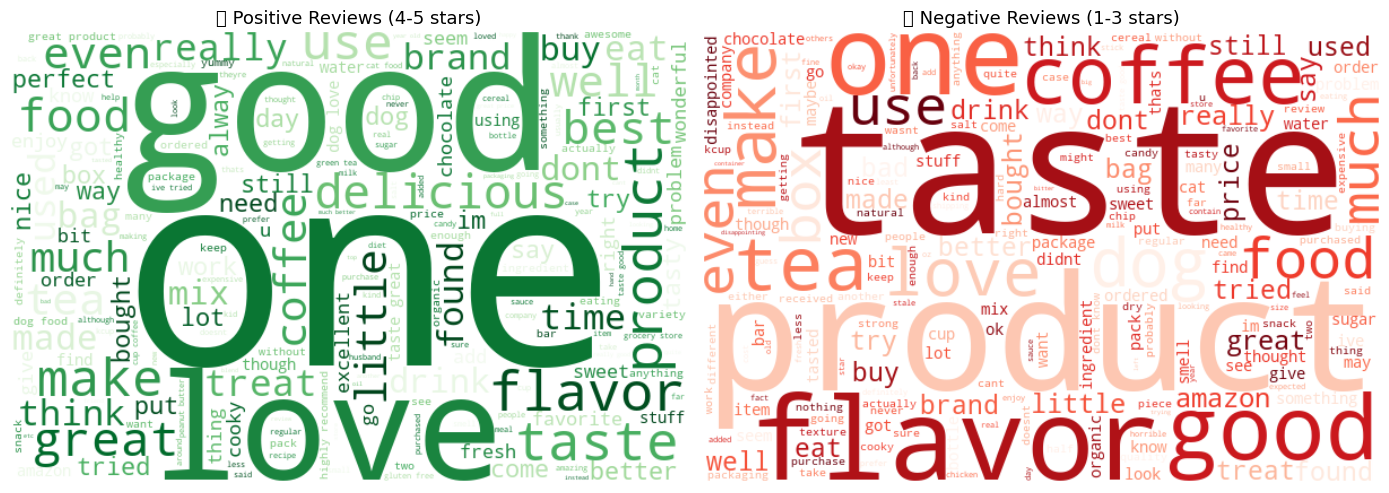

✅ Saved wordclouds.png


In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sentiment, label, color in zip(
    axes,
    [1, 0],
    ['⭐ Positive Reviews (4-5 stars)', '💢 Negative Reviews (1-3 stars)'],
    ['Greens', 'Reds']
):
    subset = df[df['sentiment'] == sentiment]['cleaned']
    text = ' '.join(subset)
    wc = WordCloud(width=600, height=400, background_color='white', colormap=color).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()
print("✅ Saved wordclouds.png")

In [7]:
from sklearn.model_selection import train_test_split

X = X_tfidf  # our TF-IDF matrix from Session 2
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nTrain sentiment split:\n{y_train.value_counts()}")

Training samples: 40000
Testing samples:  10000

Train sentiment split:
sentiment
1    31284
0     8716
Name: count, dtype: int64


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Results
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.82      0.63      0.71      2179
    Positive       0.90      0.96      0.93      7821

    accuracy                           0.89     10000
   macro avg       0.86      0.80      0.82     10000
weighted avg       0.89      0.89      0.88     10000



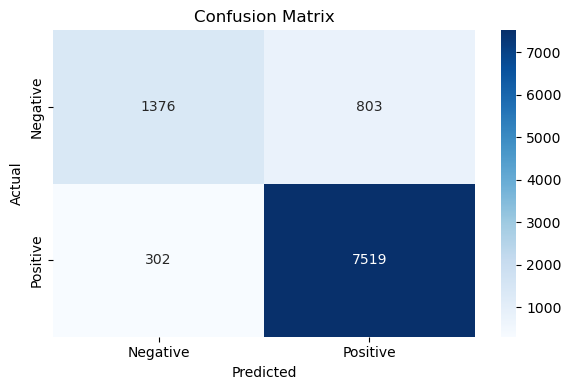

✅ Saved confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved confusion_matrix.png")

In [10]:
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lr.coef_[0]

top_positive = np.argsort(coefficients)[-15:]
top_negative = np.argsort(coefficients)[:15]

print("=== Words pushing toward POSITIVE ===")
for i in top_positive[::-1]:
    print(f"  {feature_names[i]:<20} {coefficients[i]:.3f}")

print("\n=== Words pushing toward NEGATIVE ===")
for i in top_negative:
    print(f"  {feature_names[i]:<20} {coefficients[i]:.3f}")

=== Words pushing toward POSITIVE ===
  great                10.452
  best                 8.359
  love                 8.253
  delicious            8.096
  excellent            7.299
  perfect              6.823
  wonderful            5.427
  yummy                5.395
  highly               4.927
  awesome              4.722
  amazing              4.672
  favorite             4.518
  yum                  4.474
  good                 4.405
  fantastic            4.212

=== Words pushing toward NEGATIVE ===
  ok                   -6.457
  disappointed         -6.319
  horrible             -5.666
  worst                -5.649
  disappointing        -5.363
  awful                -5.225
  unfortunately        -5.019
  terrible             -4.979
  weak                 -4.805
  okay                 -4.544
  poor                 -3.925
  stale                -3.917
  bad                  -3.718
  thought              -3.694
  waste                -3.632


In [11]:
def clean_text(text):
    # Handle missing values
    if not isinstance(text, str):
        return ''
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # 4. Keep only letters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Tokenize
    tokens = text.split()
    
    # 6. Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    
    return ' '.join(tokens)

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ============ NLP SETUP ============
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vector = tfidf_vectorizer.transform([cleaned])
    pred = lr.predict(vector)[0]
    prob = lr.predict_proba(vector)[0]
    label = "POSITIVE 😊" if pred == 1 else "NEGATIVE 😞"
    print(f"Review:     {review_text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {max(prob)*100:.1f}%")

# Try these - or write your own!
predict_sentiment("This coffee is absolutely amazing, I love it!")
print()
predict_sentiment("Terrible product, complete waste of money, never buying again.")
print()
predict_sentiment("It was okay, nothing special but not bad either.")

Review:     This coffee is absolutely amazing, I love it!
Prediction: POSITIVE 😊
Confidence: 99.9%

Review:     Terrible product, complete waste of money, never buying again.
Prediction: NEGATIVE 😞
Confidence: 99.4%

Review:     It was okay, nothing special but not bad either.
Prediction: NEGATIVE 😞
Confidence: 99.6%


In [15]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# LDA works better with BoW
lda_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=5,        # word must appear in at least 5 reviews
    max_df=0.90      # ignore words appearing in 90%+ of reviews
)

X_lda = lda_vectorizer.fit_transform(df['cleaned'])

print(f"LDA input matrix: {X_lda.shape}")
print(f"min_df and max_df filtering removed noisy/generic words")

LDA input matrix: (50000, 3000)
min_df and max_df filtering removed noisy/generic words


In [16]:
# This will take 2-3 minutes — normal!
lda_model = LatentDirichletAllocation(
    n_components=8,    # discover 8 topics
    random_state=42,
    max_iter=15,
    learning_method='online'
)

lda_model.fit(X_lda)
print("✅ LDA trained!")

✅ LDA trained!


In [17]:
vocab = lda_vectorizer.get_feature_names_out()

print("=== DISCOVERED TOPICS ===\n")
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [vocab[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Topic {topic_idx + 1}: {' | '.join(top_words)}")

=== DISCOVERED TOPICS ===

Topic 1: price | great | amazon | store | product | best | find | love | buy | good
Topic 2: make | use | mix | good | great | product | like | sauce | add | taste
Topic 3: coffee | cup | flavor | like | good | taste | great | strong | one | vanilla
Topic 4: would | product | one | bag | box | time | first | review | got | package
Topic 5: tea | taste | like | flavor | good | drink | chip | water | really | one
Topic 6: chocolate | taste | like | snack | good | great | love | bar | cooky | delicious
Topic 7: cat | food | ingredient | product | natural | energy | diet | dry | healthy | oil
Topic 8: dog | food | treat | love | like | eat | one | get | great | old


In [18]:
# Get topic distribution for each review
topic_distributions = lda_model.transform(X_lda)

# Assign dominant topic
df['dominant_topic'] = topic_distributions.argmax(axis=1) + 1

# Label them
topic_labels = {
    1: 'Shopping & Value',
    2: 'Cooking & Recipes',
    3: 'Coffee',
    4: 'Packaging & Delivery',
    5: 'Tea & Drinks',
    6: 'Snacks & Sweets',
    7: 'Cat Food & Health',
    8: 'Dog Treats'
}

df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("=== Topic Distribution ===")
print(df['topic_label'].value_counts())

=== Topic Distribution ===
topic_label
Tea & Drinks            10123
Cooking & Recipes        7641
Shopping & Value         7265
Packaging & Delivery     6864
Dog Treats               5755
Snacks & Sweets          5506
Coffee                   5403
Cat Food & Health        1443
Name: count, dtype: int64



=== Average Sentiment Score by Topic ===

                      mean  count
topic_label                      
Shopping & Value      4.57   7265
Snacks & Sweets       4.52   5506
Cooking & Recipes     4.40   7641
Dog Treats            4.38   5755
Coffee                4.26   5403
Tea & Drinks          4.08  10123
Cat Food & Health     3.86   1443
Packaging & Delivery  3.31   6864


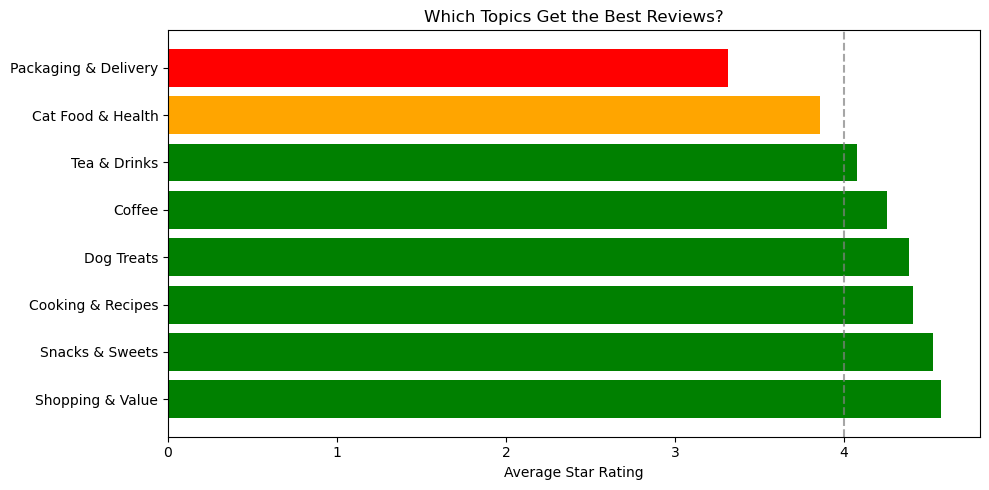

✅ Saved topic_sentiment.png


In [19]:
print("\n=== Average Sentiment Score by Topic ===\n")
topic_sentiment = df.groupby('topic_label')['Score'].agg(['mean', 'count'])
topic_sentiment = topic_sentiment.sort_values('mean', ascending=False)
print(topic_sentiment.round(2))

# Visualise
plt.figure(figsize=(10, 5))
colors = ['green' if x > 4.0 else 'orange' if x > 3.5 else 'red' 
          for x in topic_sentiment['mean']]
plt.barh(topic_sentiment.index, topic_sentiment['mean'], color=colors)
plt.axvline(x=4.0, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Average Star Rating')
plt.title('Which Topics Get the Best Reviews?')
plt.tight_layout()
plt.savefig('topic_sentiment.png', dpi=150)
plt.show()
print("✅ Saved topic_sentiment.png")

In [20]:
from gensim.models import Word2Vec

# Convert cleaned reviews into list of word lists
sentences = [review.split() for review in df['cleaned'] if isinstance(review, str)]

print(f"Total sentences: {len(sentences)}")
print(f"Sample sentence: {sentences[0][:10]}")

Total sentences: 50000
Sample sentence: ['crunchy', 'good', 'glutenfree', 'sandwich', 'cooky', 'tried', 'couple', 'brand', 'glutenfree', 'sandwich']


In [21]:
# This takes 2-3 minutes — normal!
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # each word = 100 numbers
    window=5,          # look 5 words left and right for context
    min_count=5,       # ignore words appearing fewer than 5 times
    workers=4,         # parallel processing
    epochs=10,
    seed=42
)

print(f"✅ Word2Vec trained!")
print(f"Vocabulary size: {len(w2v_model.wv)}")

✅ Word2Vec trained!
Vocabulary size: 13601


In [22]:
print("=== Words most similar to 'coffee' ===")
print(w2v_model.wv.most_similar('coffee', topn=8))

print("\n=== Words most similar to 'delicious' ===")
print(w2v_model.wv.most_similar('delicious', topn=8))

print("\n=== Words most similar to 'dog' ===")
print(w2v_model.wv.most_similar('dog', topn=8))

print("\n=== Words most similar to 'disappointed' ===")
print(w2v_model.wv.most_similar('disappointed', topn=8))

=== Words most similar to 'coffee' ===
[('expresso', 0.7691993117332458), ('coffeei', 0.7589091658592224), ('coffe', 0.7532131671905518), ('starbucks', 0.7457659840583801), ('espresso', 0.7386876940727234), ('kcup', 0.7146970629692078), ('brew', 0.7039185166358948), ('kcups', 0.6907320618629456)]

=== Words most similar to 'delicious' ===
[('yummy', 0.7837820649147034), ('tasty', 0.736677348613739), ('delish', 0.7144113779067993), ('wonderful', 0.6739475727081299), ('flavorful', 0.6059331893920898), ('fantastic', 0.5984625220298767), ('delightful', 0.5872076153755188), ('awesome', 0.5670348405838013)]

=== Words most similar to 'dog' ===
[('puppy', 0.837045431137085), ('pup', 0.8326817154884338), ('pug', 0.7619941234588623), ('chihuahua', 0.7619278430938721), ('yorkie', 0.7392534017562866), ('poodle', 0.7023221850395203), ('doggie', 0.694089412689209), ('doggy', 0.693654477596283)]

=== Words most similar to 'disappointed' ===
[('disappointing', 0.6593818068504333), ('dissapointed', 0.

In [23]:
print("=== Word Arithmetic ===\n")

# good + strong - weak = ?
result = w2v_model.wv.most_similar(
    positive=['good', 'strong'], 
    negative=['weak'], 
    topn=5
)
print("good + strong - weak =")
for word, score in result:
    print(f"  {word}: {score:.3f}")

# coffee - bitter + sweet = ?
result2 = w2v_model.wv.most_similar(
    positive=['coffee', 'sweet'], 
    negative=['bitter'], 
    topn=5
)
print("\ncoffee + sweet - bitter =")
for word, score in result2:
    print(f"  {word}: {score:.3f}")

# dog + food - treat = ?
result3 = w2v_model.wv.most_similar(
    positive=['dog', 'food'], 
    negative=['treat'], 
    topn=5
)
print("\ndog + food - treat =")
for word, score in result3:
    print(f"  {word}: {score:.3f}")

=== Word Arithmetic ===

good + strong - weak =
  great: 0.638
  decent: 0.523
  excellent: 0.518
  tasty: 0.490
  nice: 0.485

coffee + sweet - bitter =
  cappucino: 0.355
  eggnog: 0.350
  dessert: 0.347
  cappuccino: 0.342
  dessertlike: 0.341

dog + food - treat =
  purina: 0.655
  orijen: 0.654
  canidae: 0.651
  iams: 0.651
  evo: 0.639


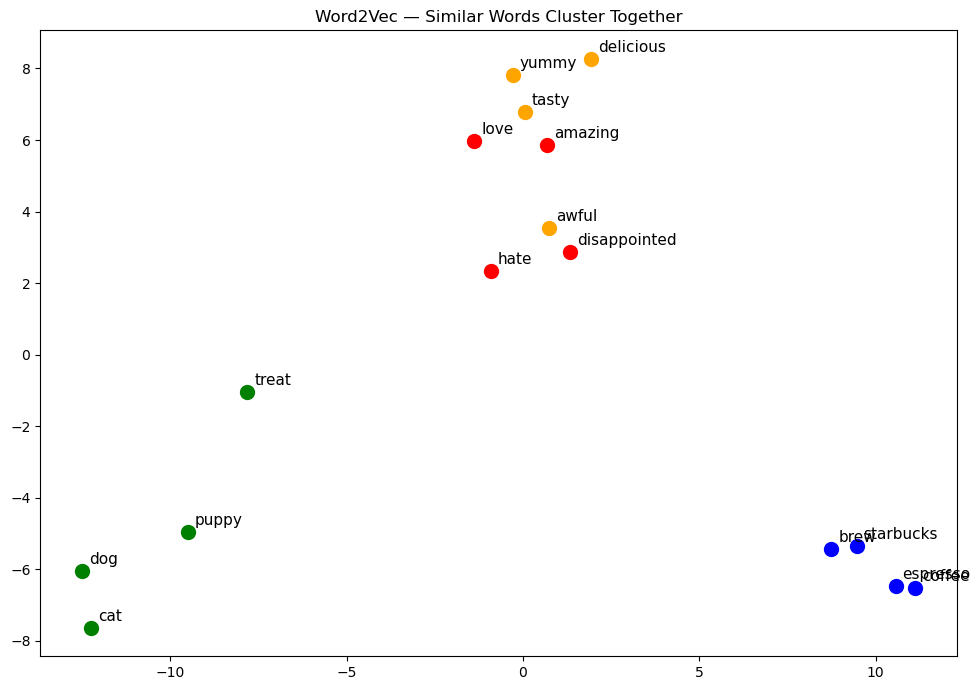

✅ Saved word2vec_clusters.png


In [24]:
from sklearn.decomposition import PCA

# Pick interesting words to visualise
words = [
    'coffee', 'espresso', 'brew', 'starbucks',
    'dog', 'cat', 'puppy', 'treat',
    'delicious', 'yummy', 'tasty', 'awful',
    'disappointed', 'love', 'hate', 'amazing'
]

# Get vectors
vectors = [w2v_model.wv[w] for w in words]

# Reduce to 2D with PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 7))
colors = ['blue']*4 + ['green']*4 + ['orange']*4 + ['red']*4

for i, word in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=100)
    plt.annotate(word, coords[i], fontsize=11,
                xytext=(5, 5), textcoords='offset points')

plt.title('Word2Vec — Similar Words Cluster Together')
plt.tight_layout()
plt.savefig('word2vec_clusters.png', dpi=150)
plt.show()
print("✅ Saved word2vec_clusters.png")

In [33]:
import spacy

nlp = spacy.load('en_core_web_sm')

# Test on a raw review (use original text, not cleaned!)
sample = df['Text'].iloc[10]
print("=== RAW REVIEW ===")
print(sample)
print("\n=== ENTITIES FOUND ===")
doc = nlp(sample)
for ent in doc.ents:
    print(f"  {ent.text:<30} → {ent.label_}")

=== RAW REVIEW ===
I am a lover of coffee and will try almost any coffee product once. I own a coffee pod maker at work, and I have been using Senseo's medium roast and espresso pods for a few months, but after trying Marley Coffee, I do not think I can go back to Senseo. I am not demeaning Senseo's quality, but I am certainly highlighting my preference for Marley Coffee. I will admit that when it comes to pod coffee, I do not expect much, and that's probably why I have stuck to only one brand; Marley Coffee, however, went beyond my expectations. I like my coffee strong; therefore, I recommend one pours no more than 6 oz. per pod for a strong flavor (this is coming from a person who drinks `straight' coffee; I never add other ingredients or sweeteners)). On a side note, there was no particular exotic/fruity taste to this coffee, but the overall quality met my expectations and passed the "will continue to buy" test. Other perks: it's organic, natural, and tasty, which, in my book, is wo

In [32]:

import sys
import subprocess

result = subprocess.run(
    [sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 6.7 MB/s eta 0:00:02
     ---- ----------------------------------- 1.6/12.8 MB 5.6 MB/s eta 0:00:03
     -------- ------------------------------- 2.6/12.8 MB 4.7 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.6 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 4.3 MB/s eta 0:00:03
     --------------- ------------------------ 5.0/12.8 MB 4.3 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 3.7 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 3.9 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 3.9 MB/s eta 0:00:02
     --------------------------- ------------ 8.7/12.8 MB 3.8 MB/s eta 0:00:02
     ----------------------------- ---------- 9.4/12.8 MB 3

In [34]:

from collections import Counter

# Run on a sample of 1000 reviews (full 50k would take too long)
brand_mentions = Counter()
product_mentions = Counter()

for review in df['Text'].iloc[:1000]:
    if not isinstance(review, str):
        continue
    doc = nlp(review)
    for ent in doc.ents:
        if ent.label_ == 'ORG':
            brand_mentions[ent.text.strip()] += 1
        elif ent.label_ == 'PRODUCT':
            product_mentions[ent.text.strip()] += 1

print("=== Top 15 Brands/Orgs Mentioned ===")
for name, count in brand_mentions.most_common(15):
    print(f"  {name:<25} {count}")

print("\n=== Top 10 Products Mentioned ===")
for name, count in product_mentions.most_common(10):
    print(f"  {name:<25} {count}")










=== Top 15 Brands/Orgs Mentioned ===
  Amazon                    133
  Starbucks                 10
  MSG                       8
  Senseo                    7
  Whole Foods               6
  AeroGarden                6
  LOVED                     5
  LOT                       5
  Costco                    5
  Wellness                  5
  Amazon.com                5
  BBQ                       4
  K-Cups                    4
  Numi                      4
  Coconut                   4

=== Top 10 Products Mentioned ===
  Red Espresso              2
  MiO                       2
  Tazo                      2
  Sprite                    2
  Byetta                    1
  who:<br                   1
  Shrimp                    1
  Nut Delight               1
  Made                      1
  Whiskas Temptation        1


In [37]:
from textblob import TextBlob

# Install if needed
try:
    from textblob import TextBlob
except:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'textblob'])
    from textblob import TextBlob

brand_sentiments = {}

for review in df['Text'].iloc[:1000]:
    if not isinstance(review, str):
        continue
    doc = nlp(review)
    sentiment = TextBlob(review).sentiment.polarity
    for ent in doc.ents:
        if ent.label_ == 'ORG':
            brand = ent.text.strip()
            if brand not in brand_sentiments:
                brand_sentiments[brand] = []
            brand_sentiments[brand].append(sentiment)

# Only show brands mentioned 3+ times
print("=== Brand Sentiment (min 3 mentions) ===\n")
brand_summary = {
    brand: (sum(scores)/len(scores), len(scores))
    for brand, scores in brand_sentiments.items()
    if len(scores) >= 3
}

for brand, (avg_sentiment, count) in sorted(brand_summary.items(), 
                                             key=lambda x: x[1][0], 
                                             reverse=True)[:10]:
    bar = '🟢' if avg_sentiment > 0.2 else '🟡' if avg_sentiment > 0 else '🔴'
    print(f"{bar} {brand:<25} sentiment: {avg_sentiment:.2f}  mentions: {count}")

=== Brand Sentiment (min 3 mentions) ===

🟢 Weaver                    sentiment: 0.45  mentions: 3
🟢 LOVED                     sentiment: 0.33  mentions: 5
🟢 Walmart                   sentiment: 0.30  mentions: 3
🟢 Weight Watchers           sentiment: 0.30  mentions: 3
🟢 LOT                       sentiment: 0.29  mentions: 5
🟢 Coconut                   sentiment: 0.28  mentions: 4
🟢 Vanilla                   sentiment: 0.27  mentions: 3
🟢 AeroGarden                sentiment: 0.26  mentions: 6
🟢 PB2                       sentiment: 0.24  mentions: 3
🟢 Amazon.com                sentiment: 0.22  mentions: 5


In [36]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'textblob'])
subprocess.run([sys.executable, '-m', 'textblob.download_corpora'])
print("✅ TextBlob ready")

✅ TextBlob ready


In [38]:
# Filter out obvious non-brands
false_positives = ['LOVED', 'LOT', 'Coconut', 'Vanilla', 'Amazon.com', 
                   'ONE', 'TWO', 'WOW', 'OMG']

print("=== Top Brands Mentioned (cleaned) ===")
for name, count in brand_mentions.most_common(20):
    if name not in false_positives and len(name) > 2:
        print(f"  {name:<25} {count} mentions")

=== Top Brands Mentioned (cleaned) ===
  Amazon                    133 mentions
  Starbucks                 10 mentions
  MSG                       8 mentions
  Senseo                    7 mentions
  Whole Foods               6 mentions
  AeroGarden                6 mentions
  Costco                    5 mentions
  Wellness                  5 mentions
  BBQ                       4 mentions
  K-Cups                    4 mentions
  Numi                      4 mentions
  CTC                       4 mentions
  Marley Coffee             3 mentions
  Stash                     3 mentions
  Walmart                   3 mentions
  Weight Watchers           3 mentions
